# Payne Zero tutorial

This notebook builds a spectrum one physical layer at a time. It covers synthesis from an existing atmosphere, a new atmosphere calculation, differentiable line-list calibration, a controlled normalized-spectrum fit, and an APOGEE fit with inverse variances, continuum profiling, velocity, broadening, and the measured line-spread function (LSF).

The same cells select NVIDIA CUDA, Apple Metal, or CPU automatically. A CUDA GPU is recommended for the APOGEE fit. CPU execution is scientifically equivalent but slower.

## 1. Imports and device selection

The environment variable `PAYNE_ZERO_DEVICE` can force `cpu`, `mps`, or `cuda`. Without it, the notebook chooses CUDA, then Apple Metal, then CPU.

The tutorial uses NumPy for arrays, PyTorch for device selection, and Matplotlib for compact diagnostics. No private research modules are required.

In [1]:
import json
import os
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

Device selection is explicit and portable. `auto` prefers an NVIDIA CUDA GPU, then Apple Metal, and finally CPU. CPU uses float64; the GPU paths use float32.

In [2]:
requested = os.getenv("PAYNE_ZERO_DEVICE", "auto")
available = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device = available if requested == "auto" else requested
if device == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA was requested but is unavailable")
if device == "mps" and not torch.backends.mps.is_available():
    raise RuntimeError("Apple Metal was requested but is unavailable")
dtype_name = "float64" if device == "cpu" else "float32"
torch_dtype = torch.float64 if dtype_name == "float64" else torch.float32
print(f"device={device}, synthesis dtype={dtype_name}")

device=mps, synthesis dtype=float32


The bundled examples are read from `examples/data/`. Generated products go under the ignored `tutorial_output/` directory.

In [3]:
repo = Path.cwd().resolve()
if not (repo / "pyproject.toml").is_file():
    repo = repo.parent
if not (repo / "pyproject.toml").is_file():
    raise RuntimeError("Run this notebook from the Payne Zero repository or its examples directory")
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))
data_dir = repo / "examples" / "data"
output_dir = repo / "tutorial_output"
output_dir.mkdir(exist_ok=True)

## 2. Synthesis from an existing atmosphere

A structured atmosphere is the boundary between the CPU atmosphere solver and spectrum synthesis. We first validate the bundled solar example, then synthesize a small optical interval.

A structured-atmosphere NPZ is the public boundary between atmosphere calculation and synthesis. Validate it before a long calculation.

In [4]:
from payne_zero_synthesis import synthesize, validate_atmosphere_npz

sun_atmosphere = data_dir / "sun_structured_atmosphere.npz"
fields = validate_atmosphere_npz(sun_atmosphere)
print(f"{len(fields)} validated atmosphere arrays")

25 validated atmosphere arrays


Synthesis needs only an atmosphere, wavelength interval, intrinsic sampling density, and device. This narrow window keeps the first example quick on every backend.

In [5]:
solar_spectrum = synthesize(
    sun_atmosphere,
    wavelength_start_nm=500.0,
    wavelength_end_nm=510.0,
    resolution=20_000,
    device=device,
    dtype=dtype_name,
)
print(f"{solar_spectrum.wavelength_nm.size} samples in {solar_spectrum.seconds:.2f} s")

396 samples in 1.86 s


Inspect the spectrum rather than relying only on a successful return value.

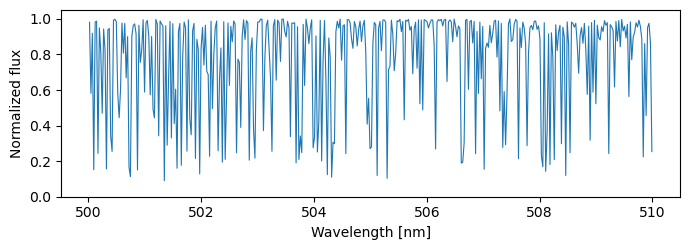

In [6]:
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(solar_spectrum.wavelength_nm, solar_spectrum.normalized_flux, lw=0.8)
ax.set(xlabel="Wavelength [nm]", ylabel="Normalized flux", ylim=(0, 1.05))
fig.tight_layout()

## 3. Atmosphere plus synthesis

The high-level atmosphere API predicts a starting depth structure and then runs the physical solver to convergence. The returned NPZ can be passed directly to the same synthesis call.

Now calculate the depth structure instead of reading one. The five-label initializer supplies a starting state, and the physical solver establishes the returned atmosphere.

In [7]:
from payne_zero_atmosphere import solve_structured_atmosphere

solved_atmosphere = output_dir / "solar_atmosphere" / "payne_zero_structured_atmosphere.npz"
if not solved_atmosphere.is_file():
    solved_atmosphere = solve_structured_atmosphere(
        effective_temperature=5777.0,
        log_surface_gravity=4.44,
        metallicity=0.0,
        alpha_enhancement=0.0,
        microturbulence_km_s=2.0,
        out_dir=solved_atmosphere.parent,
    )
print(solved_atmosphere.relative_to(repo))

tutorial_output/solar_atmosphere/payne_zero_structured_atmosphere.npz


The newly converged product enters the same synthesis function as the bundled atmosphere.

In [8]:
solved_spectrum = synthesize(
    solved_atmosphere,
    wavelength_start_nm=500.0,
    wavelength_end_nm=510.0,
    resolution=20_000,
    device=device,
    dtype=dtype_name,
)

Inspect the spectrum rather than relying only on a successful return value.

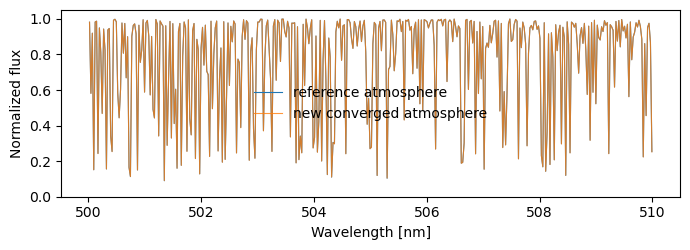

In [9]:
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(solar_spectrum.wavelength_nm, solar_spectrum.normalized_flux, label="reference atmosphere", lw=0.8)
ax.plot(solved_spectrum.wavelength_nm, solved_spectrum.normalized_flux, label="new converged atmosphere", lw=0.8, alpha=0.8)
ax.set(xlabel="Wavelength [nm]", ylabel="Normalized flux", ylim=(0, 1.05))
ax.legend(frameon=False)
fig.tight_layout()

The five-label solver used above also accepts `[M/H]`, `[alpha/M]`, and microturbulence. Adding `c_over_m`, `n_over_m`, and `o_over_m` selects the eight-label initializer. An installation that includes the optional direct-abundance checkpoint can instead supply individual keywords such as `fe_over_h` and `mg_over_h`; the physical solver still establishes the final atmosphere.

## 4. Differentiable line-list calibration

The calibration API only requires observed flux, nonnegative weights, bounded parameters, and a differentiable Torch callback. This compact two-star example fits two oscillator-strength corrections simultaneously.

Line calibration treats continuous atomic parameters as trainable values. This compact synthetic example exposes the same multi-spectrum interface used for standard-star calibration.

In [10]:
from linelist_calibration import calibrate_line_parameters
from linelist_calibration.examples.fit_synthetic_standard_stars import build_example

calibration_data, calibration_config, calibration_model = build_example()
calibration_config = replace(calibration_config, device=device, dtype=dtype_name)

The optimizer updates all active line parameters jointly and records the objective after each evaluation.

In [11]:
calibration = calibrate_line_parameters(
    calibration_data,
    calibration_config,
    calibration_model,
)
dict(zip(calibration.names, calibration.values, strict=True))

{'Fe_I_1569_loggf_dex': np.float64(0.08000028133392334),
 'Si_I_1589_loggf_dex': np.float64(-0.11999925971031189)}

A declining objective provides the first calibration diagnostic. Physical applications should also inspect the fitted line profiles.

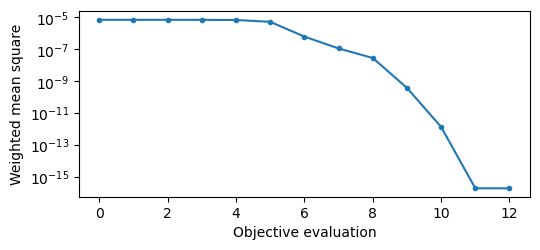

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 2.6))
ax.semilogy(calibration.loss_history, marker="o", ms=3)
ax.set(xlabel="Objective evaluation", ylabel="Weighted mean square")
fig.tight_layout()

In a physical calibration, the callback replaces the analytic line profiles with Payne Zero synthesis and can expose oscillator strengths plus van der Waals, radiative, and Stark damping parameters. Multiple standards are concatenated in the same objective, so blended lines are optimized jointly.

## 5. Controlled normalized-spectrum fit

This is the optimizer pattern used in the controlled experiment in Section 5 of the paper. The model has two nonlinear line depths. A linear continuum is solved exactly at every trial rather than added to the nonlinear parameter vector.

The generic fitter requires an observed spectrum, parameter bounds, and a callable that returns normalized model flux. Two analytic absorption lines make the parameter recovery transparent.

In [13]:
from fitter import FitConfiguration, NormalizedSpectrum, fit_normalized_spectrum

wavelength = np.linspace(500.0, 510.0, 600)
profiles = np.column_stack([
    np.exp(-0.5 * ((wavelength - 503.0) / 0.08) ** 2),
    np.exp(-0.5 * ((wavelength - 507.0) / 0.12) ** 2),
])
def model(p):
    return 1.0 - profiles @ p

Create a noisy mock spectrum with a low-order multiplicative continuum. The fixed random seed makes the result reproducible.

In [14]:
truth = np.array([0.25, 0.12])
coordinate = (wavelength - wavelength.mean()) / np.ptp(wavelength)
continuum_basis = np.column_stack([np.ones(wavelength.size), coordinate])
rng = np.random.default_rng(42)
observed = model(truth) * (1.0 + continuum_basis @ [0.012, -0.006])
observed += rng.normal(0.0, 0.002, wavelength.size)

Inverse variance and the pixel mask belong to the observation. Bounds, finite-difference steps, and trust widths belong to the fit configuration.

In [15]:
mock = NormalizedSpectrum(
    wavelength=wavelength,
    flux=observed,
    inverse_variance=np.full(wavelength.size, 0.002**-2),
    mask=np.ones(wavelength.size, dtype=bool),
)
fit_config = FitConfiguration(
    names=("line_a", "line_b"),
    initial=np.array([0.10, 0.25]),
    lower=np.zeros(2),
    upper=np.full(2, 0.5),
    derivative_steps=np.full(2, 0.01),
    trust_half_width=np.full(2, 0.2),
    maximum_iterations=6,
)

The fitter profiles the linear continuum while optimizing the nonlinear line depths.

In [16]:
mock_fit = fit_normalized_spectrum(
    mock,
    fit_config,
    model,
    continuum_basis=continuum_basis,
)
print("truth:", truth)
print("fit:  ", mock_fit.parameters)

truth: [0.25 0.12]
fit:   [0.24916189 0.12026328]


Inspect the spectrum rather than relying only on a successful return value.

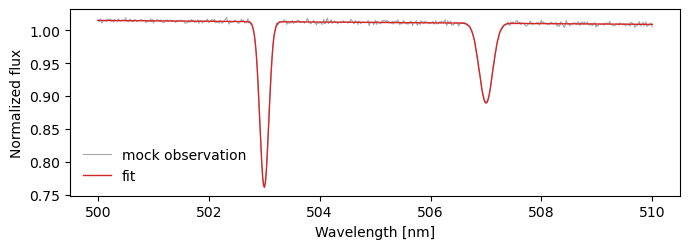

In [17]:
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(wavelength, observed, color="0.65", lw=0.8, label="mock observation")
ax.plot(wavelength, mock_fit.model_flux, color="C3", lw=1.0, label="fit")
ax.set(xlabel="Wavelength [nm]", ylabel="Normalized flux")
ax.legend(frameon=False)
fig.tight_layout()

## 6. APOGEE spectrum with LSF, kinematics, and continuum

The bundled example is a public APOGEE DR14 combined spectrum on the 7,514 retained pixels expected by the adapter. Its inverse variance and mask enter the objective directly. The fitter synthesizes an intrinsic spectrum, applies Gaussian macroscopic broadening and a residual Doppler shift, convolves total and continuum flux with the wavelength-dependent APOGEE LSF, samples the detector grid, and profiles one Legendre continuum per detector chip.

This compact demonstration fits five atmospheric labels plus velocity and broadening. It also applies the released Sun–Arcturus line calibration. The paper's survey experiment uses the same instrument path with twelve independent abundances and a final converged-atmosphere check.

The survey example is a real APOGEE DR14 spectrum bundled with its pixel mask, inverse variance, initial stellar labels, and mean line-spread function.

In [18]:
with np.load(data_dir / "apogee_dr14_example.npz", allow_pickle=False) as source:
    apogee = {name: np.asarray(source[name]) for name in source.files}
metadata = json.loads((data_dir / "apogee_dr14_example.json").read_text())
reference_labels = np.array([
    metadata["effective_temperature"],
    metadata["log_surface_gravity"],
    metadata["metallicity"],
    metadata["alpha_enhancement"],
    metadata["microturbulence_km_s"],
])

Inspect the spectrum rather than relying only on a successful return value.

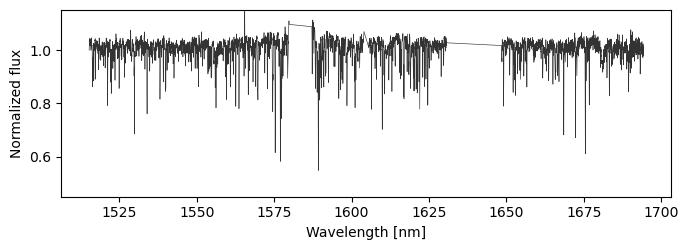

In [19]:
fig, ax = plt.subplots(figsize=(7, 2.6))
good = apogee["good_pixel_mask"]
ax.plot(apogee["wavelength_nm"][good], apogee["normalized_flux"][good], color="0.2", lw=0.45)
ax.set(xlabel="Wavelength [nm]", ylabel="Normalized flux", ylim=(0.45, 1.15))
fig.tight_layout()

`fit_apogee_spectrum` keeps the instrument operations in the same forward model. The LSF convolution, residual velocity, Gaussian broadening, detector sampling, and continuum profiling are applied for every trial.

In [20]:
from fitter.apogee import fit_apogee_spectrum

apogee_result_dir = output_dir / "apogee_fit"
atomic_calibration = (
    repo / "linelist_calibration" / "data" / "sun_arcturus_fts_hband_shared.npz"
)

Observed arrays and starting labels are separated from numerical options so each part of the call remains easy to adapt.

In [21]:
apogee_inputs = {
    "object_id": metadata["object_id"],
    "wavelength_nm": apogee["wavelength_nm"],
    "normalized_flux": apogee["normalized_flux"],
    "inverse_variance": apogee["inverse_variance"],
    "good_pixel_mask": apogee["good_pixel_mask"],
    "reference_labels": reference_labels,
    "reference_vmacro_km_s": metadata["macroscopic_broadening_km_s"],
}

The tutorial uses a moderate intrinsic grid for portability. Production work can increase `synthesis_r_grid` without changing the fitting interface.

In [22]:
apogee_summary = fit_apogee_spectrum(
    apogee_result_dir,
    **apogee_inputs,
    device=device,
    dtype=dtype_name,
    synthesis_r_grid=50_000,
    fresh_jacobian_rounds=0,
    continuum_order=2,
    atomic_calibration_path=atomic_calibration,
    compact_trace=False,
    force=True,
)

Read the selected physical and nuisance parameters together with the inverse-variance-weighted fit statistic.

In [23]:
print("selected parameters")
for name, value in apogee_summary["selected_parameters"].items():
    print(f"  {name}: {value:.5g}")
print(f"reduced chi-square: {apogee_summary['reduced_chi_square']:.3f}")

selected parameters
  effective_temperature: 4630.8
  log_surface_gravity: 2.658
  metallicity: -0.56634
  alpha_enhancement: 0.10569
  microturbulence_km_s: 2.2554
  residual_rv_km_s: 0.88688
  vmacro_km_s: 3.0272
reduced chi-square: 3.801


The trace stores the model at each accepted evaluation. Select the model named by the summary rather than assuming the final array row.

In [24]:
with np.load(apogee_result_dir / "trace" / "optimization_trace.npz", allow_pickle=False) as trace:
    fitted_apogee_flux = trace["normalized_model_flux"][apogee_summary["selected_evaluation"]]

Finally inspect a representative wavelength interval. The lower panel compares the residual with the reported one-sigma uncertainty.

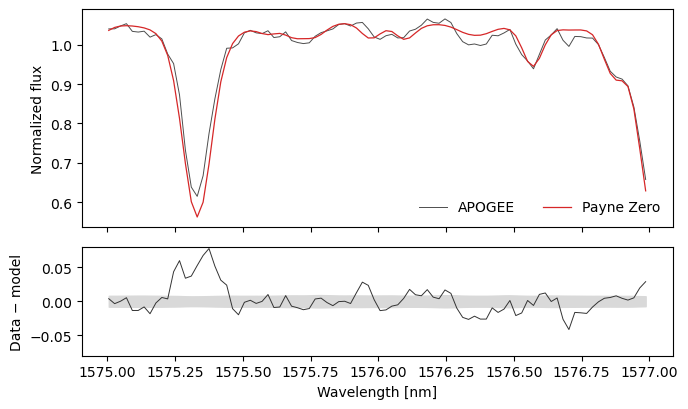

In [25]:
region = (apogee["wavelength_nm"] > 1575.0) & (apogee["wavelength_nm"] < 1577.0) & good
uncertainty = np.zeros_like(apogee["inverse_variance"], dtype=float)
uncertainty[good] = apogee["inverse_variance"][good] ** -0.5
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7, 4.2), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
top.plot(apogee["wavelength_nm"][region], apogee["normalized_flux"][region], color="0.3", lw=0.7, label="APOGEE")
top.plot(apogee["wavelength_nm"][region], fitted_apogee_flux[region], color="C3", lw=0.9, label="Payne Zero")
top.legend(frameon=False, ncol=2)
top.set_ylabel("Normalized flux")
residual = apogee["normalized_flux"] - fitted_apogee_flux
bottom.fill_between(apogee["wavelength_nm"][region], -uncertainty[region], uncertainty[region], color="0.85")
bottom.plot(apogee["wavelength_nm"][region], residual[region], color="0.2", lw=0.7)
bottom.set(xlabel="Wavelength [nm]", ylabel="Data − model", ylim=(-0.08, 0.08))
fig.tight_layout()

The tutorial uses `R_grid=50,000` to keep CPU and laptop execution practical while resolving the intrinsic spectrum before LSF convolution. Production APOGEE work in the paper uses `R_grid=300,000` and fits twelve abundance coordinates rather than the five-label parameterization above. The final scientific step is the same in either case. Pass the selected atmosphere labels and abundance mixture to `solve_structured_atmosphere`, resynthesize with the same instrument operator, and retain the result only after the physical-atmosphere check described in `fitter/README.md`.